# 04. Qwen3 Embedding Modeling

In [1]:
from pathlib import Path
import gc
import hashlib
import importlib.util
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sentence_transformers import SentenceTransformer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
import torch

sns.set_theme(style='whitegrid')
DATA_PATH = Path('../data/processed/reviews_dataset.csv')
EMBEDDING_DIR = Path('../data/processed/embeddings')
df = pd.read_csv(DATA_PATH)
class_order = ['newbie', 'casual', 'engaged', 'veteran']

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.1+cu118).
W0516 14:51:06.388000 5932 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
target = 'experience_class'
text_column = 'review'
base_metadata_columns = [
    'game', 
    'game_group', 
    'voted_up', 
    'votes_up', 
    'votes_funny', 
    'weighted_vote_score',
    'comment_count', 
    'steam_purchase', 
    'received_for_free',
    'written_during_early_access', 
    'author_num_games_owned',
    'author_num_reviews',
]

In [3]:
MODEL_NAME = 'Qwen/Qwen3-Embedding-0.6B'
BATCH_SIZE = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_SEQ_LENGTH = 1024
NORMALIZE_EMBEDDINGS = True
DEVICE_MAP = 'auto'
TOKENIZER_PADDING_SIDE = 'left'

REQUEST_FLASH_ATTENTION_2 = True
FLASH_ATTENTION_2_AVAILABLE = importlib.util.find_spec('flash_attn') is not None
USE_FLASH_ATTENTION_2 = REQUEST_FLASH_ATTENTION_2 and FLASH_ATTENTION_2_AVAILABLE

EMBEDDING_PREFIX = ''

##### Функции для выбора среза данных

In [4]:
def subset_by_group(data, group):
    if group == 'all':
        return data.copy()
    return data[data['game_group'] == group].copy()


def text_fingerprint(texts, model_name, prefix, normalize_embeddings):
    payload = {
        'model_name': model_name,
        'prefix': prefix,
        'normalize_embeddings': normalize_embeddings,
        'max_seq_length': MAX_SEQ_LENGTH,
        'use_flash_attention_2': USE_FLASH_ATTENTION_2,
        'device_map': DEVICE_MAP if USE_FLASH_ATTENTION_2 else None,
        'tokenizer_padding_side': TOKENIZER_PADDING_SIDE,
        'texts': list(texts),
    }
    encoded = json.dumps(payload, ensure_ascii=False, sort_keys=True).encode('utf-8')
    return hashlib.sha256(encoded).hexdigest()[:16]


def cache_paths(fingerprint):
    EMBEDDING_DIR.mkdir(parents=True, exist_ok=True)
    return {
        'embeddings': EMBEDDING_DIR / f'qwen3_06b_{fingerprint}.npy',
        'metadata': EMBEDDING_DIR / f'qwen3_06b_{fingerprint}.json',
    }

##### Функции для построения моделей

In [5]:
def build_embedding_texts(texts, prefix):
    if not prefix:
        return [str(text) for text in texts]
    return [prefix + str(text) for text in texts]


def build_sentence_transformer():
    sentence_transformer_kwargs = {
        'tokenizer_kwargs': {'padding_side': TOKENIZER_PADDING_SIDE},
    }
    if USE_FLASH_ATTENTION_2:
        sentence_transformer_kwargs['model_kwargs'] = {
            'attn_implementation': 'flash_attention_2',
            'device_map': DEVICE_MAP,
        }
    elif DEVICE is not None:
        sentence_transformer_kwargs['device'] = DEVICE

    model = SentenceTransformer(MODEL_NAME, **sentence_transformer_kwargs)
    model.max_seq_length = MAX_SEQ_LENGTH
    return model


def load_or_create_embeddings(texts):
    fingerprint = text_fingerprint(texts, MODEL_NAME, EMBEDDING_PREFIX, NORMALIZE_EMBEDDINGS)
    paths = cache_paths(fingerprint)

    if paths['embeddings'].exists() and paths['metadata'].exists():
        print(f"Loading cached embeddings from {paths['embeddings']}")
        return np.load(paths['embeddings'])

    print(f"Loading embedding model: {MODEL_NAME}")
    model = build_sentence_transformer()
    print(f'Model max_seq_length: {model.max_seq_length}')

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    embedding_texts = build_embedding_texts(texts, EMBEDDING_PREFIX)
    embeddings = model.encode(
        embedding_texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=NORMALIZE_EMBEDDINGS,
    ).astype(np.float32)

    np.save(paths['embeddings'], embeddings)
    paths['metadata'].write_text(
        json.dumps(
            {
                'model_name': MODEL_NAME,
                'rows': len(texts),
                'embedding_dim': int(embeddings.shape[1]),
                'normalize_embeddings': NORMALIZE_EMBEDDINGS,
                'max_seq_length': MAX_SEQ_LENGTH,
                'use_flash_attention_2': USE_FLASH_ATTENTION_2,
                'device_map': DEVICE_MAP if USE_FLASH_ATTENTION_2 else None,
                'tokenizer_padding_side': TOKENIZER_PADDING_SIDE,
                'prefix': EMBEDDING_PREFIX,
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding='utf-8',
    )
    print(f"Saved embeddings to {paths['embeddings']}")
    return embeddings

##### Построение эмбеддингов

In [6]:
qwen_embeddings = load_or_create_embeddings(df[text_column].fillna('').astype(str).tolist())
qwen_embeddings.shape

Loading cached embeddings from ..\data\processed\embeddings\qwen3_06b_e9c244177fcbf243.npy


(7467, 1024)

##### Функции для построения моделей

In [7]:
def build_metadata_preprocessor(metadata_columns):
    categorical_features = [
        column for column in [
            'game', 'game_group', 'voted_up', 'steam_purchase',
            'received_for_free', 'written_during_early_access',
        ]
        if column in metadata_columns
    ]
    numeric_features = [column for column in metadata_columns if column not in categorical_features]

    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False)),
        ]), numeric_features),
        ('cat', Pipeline([
            ('to_object', FunctionTransformer(lambda values: values.astype(object), validate=False)),
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ], remainder='drop')


def build_qwen_logreg(X_train_embeddings, y_train):
    model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
    model.fit(X_train_embeddings, y_train)
    return model


def predict_qwen_logreg(model, X_embeddings):
    return model.predict(X_embeddings)


def build_qwen_metadata_logreg(X_train, X_train_embeddings, y_train, metadata_columns):
    metadata_preprocess = build_metadata_preprocessor(metadata_columns)
    X_train_metadata = metadata_preprocess.fit_transform(X_train[metadata_columns])
    X_train_features = sparse.hstack([sparse.csr_matrix(X_train_embeddings), X_train_metadata]).tocsr()

    model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
    model.fit(X_train_features, y_train)
    return {
        'model': model,
        'metadata_preprocess': metadata_preprocess,
        'metadata_columns': metadata_columns,
    }


def predict_qwen_metadata_logreg(bundle, X, X_embeddings):
    X_metadata = bundle['metadata_preprocess'].transform(X[bundle['metadata_columns']])
    X_features = sparse.hstack([sparse.csr_matrix(X_embeddings), X_metadata]).tocsr()
    return bundle['model'].predict(X_features)

##### Функция обучения и оценки моделей

In [8]:
def evaluate_group(data, embeddings, group_name):
    group_df = subset_by_group(data, group_name)
    group_embeddings = embeddings[group_df.index.to_numpy()]
    metadata_columns = [column for column in base_metadata_columns if column in group_df.columns]
    X = group_df[[text_column] + metadata_columns].copy()
    y = group_df[target].astype(str)

    indices = np.arange(len(group_df))
    train_idx, test_idx, y_train, y_test = train_test_split(
        indices, y, test_size=0.2, random_state=42, stratify=y
    )

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    X_train_embeddings = group_embeddings[train_idx]
    X_test_embeddings = group_embeddings[test_idx]

    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_train_embeddings, y_train)
    dummy_predictions = dummy.predict(X_test_embeddings)

    qwen_only = build_qwen_logreg(X_train_embeddings, y_train)
    qwen_only_predictions = predict_qwen_logreg(qwen_only, X_test_embeddings)

    qwen_metadata = build_qwen_metadata_logreg(X_train, X_train_embeddings, y_train, metadata_columns)
    qwen_metadata_predictions = predict_qwen_metadata_logreg(qwen_metadata, X_test, X_test_embeddings)

    predictions_by_model = {
        'dummy_most_frequent': dummy_predictions,
        'qwen_only': qwen_only_predictions,
        'qwen_metadata': qwen_metadata_predictions,
    }
    fitted_models = {
        'dummy_most_frequent': dummy,
        'qwen_only': qwen_only,
        'qwen_metadata': qwen_metadata,
    }

    rows = []
    for model_name, predictions in predictions_by_model.items():
        rows.append({
            'game_group': group_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test, predictions),
            'macro_f1': f1_score(y_test, predictions, average='macro'),
        })

    results = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
    best_name = results.iloc[0]['model']
    return {
        'group_name': group_name,
        'data': group_df,
        'results': results,
        'best_name': best_name,
        'best_model': fitted_models[best_name],
        'best_predictions': predictions_by_model[best_name],
        'X_test': X_test,
        'y_test': y_test,
    }

##### Обучение моделей и сводная таблица метрик

In [9]:
group_runs = {group: evaluate_group(df, qwen_embeddings, group) for group in ['all', 'offline', 'competitive']}
all_results = pd.concat([run['results'] for run in group_runs.values()], ignore_index=True)
all_results.sort_values(['game_group', 'macro_f1'], ascending=[True, False])

,game_group,model,accuracy,macro_f1
0,all,qwen_metadata,0.512718,0.510654
1,all,qwen_only,0.478581,0.470351
2,all,dummy_most_frequent,0.371486,0.135432
6,competitive,qwen_metadata,0.443131,0.436692
7,competitive,qwen_only,0.407681,0.391994
8,competitive,dummy_most_frequent,0.311669,0.118806
3,offline,qwen_metadata,0.522005,0.483772
4,offline,qwen_only,0.475550,0.443925
5,offline,dummy_most_frequent,0.480440,0.162263


##### Сравнение `macro_f1` моделей по группам

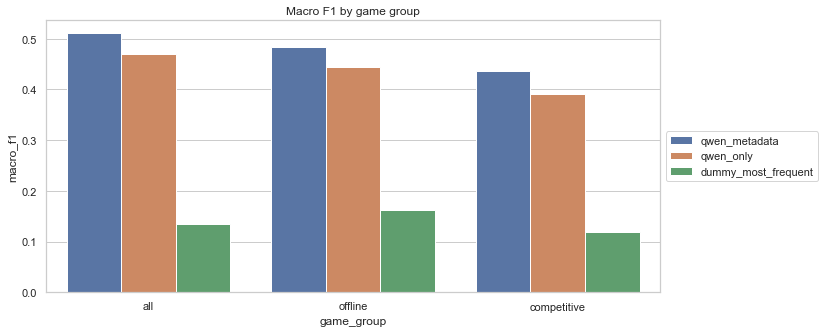

In [10]:
plt.figure(figsize=(11, 5))
sns.barplot(data=all_results, x='game_group', y='macro_f1', hue='model')
plt.title('Macro F1 by game group')
plt.xlabel('game_group')
plt.ylabel('macro_f1')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

##### Confusion matrix для лучшей модели в каждом срезе

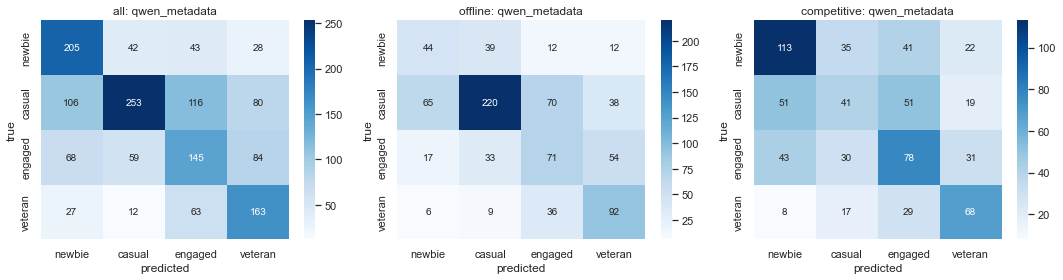

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_name in zip(axes, ['all', 'offline', 'competitive']):
    run = group_runs[group_name]
    matrix = confusion_matrix(run['y_test'], run['best_predictions'], labels=class_order)
    sns.heatmap(matrix, annot=True, fmt='d', xticklabels=class_order, yticklabels=class_order, cmap='Blues', ax=ax)
    ax.set_title(f"{group_name}: {run['best_name']}")
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
plt.tight_layout()
plt.show()

##### Classification report для каждого среза

In [12]:
for group_name in ['all', 'offline', 'competitive']:
    run = group_runs[group_name]
    print(f"\n{group_name}: {run['best_name']}")
    print(classification_report(run['y_test'], run['best_predictions'], labels=class_order, zero_division=0))


all: qwen_metadata
              precision    recall  f1-score   support

      newbie       0.50      0.64      0.57       318
      casual       0.69      0.46      0.55       555
     engaged       0.40      0.41      0.40       356
     veteran       0.46      0.62      0.53       265

    accuracy                           0.51      1494
   macro avg       0.51      0.53      0.51      1494
weighted avg       0.54      0.51      0.51      1494


offline: qwen_metadata
              precision    recall  f1-score   support

      newbie       0.33      0.41      0.37       107
      casual       0.73      0.56      0.63       393
     engaged       0.38      0.41      0.39       175
     veteran       0.47      0.64      0.54       143

    accuracy                           0.52       818
   macro avg       0.48      0.51      0.48       818
weighted avg       0.56      0.52      0.53       818


competitive: qwen_metadata
              precision    recall  f1-score   support

   

##### Примеры ошибок модели

In [13]:
error_tables = []
for group_name in ['all', 'offline', 'competitive']:
    run = group_runs[group_name]
    errors = run['X_test'].copy()
    errors['game_group_view'] = group_name
    errors['true_class'] = run['y_test'].values
    errors['predicted_class'] = run['best_predictions']
    errors = errors[errors['true_class'] != errors['predicted_class']]
    error_tables.append(errors[['game_group_view', 'game', 'true_class', 'predicted_class', 'review']].head(3))

pd.concat(error_tables, ignore_index=True)

,game_group_view,game,true_class,predicted_class,review
0,all,Apex Legends,veteran,engaged,"Dollar Store Servers, Hackers Rampant despite ..."
1,all,Red Dead Redemption 2,casual,veteran,Amazing game amazing graphics. Only thing is i...
2,all,Counter-Strike 2,casual,newbie,Counter-Strike still hits a little different f...
3,offline,Red Dead Redemption 2,engaged,veteran,"Best game ever, the characters feel real, the ..."
4,offline,Black Myth: Wukong,casual,engaged,"Wukong was absolutely amazing — fun, challengi..."
5,offline,Black Myth: Wukong,casual,newbie,"Flat, unsatisfying combat that is mostly carri..."
6,competitive,PUBG: Battlegrounds,newbie,casual,"Fix the damn game, ♥♥♥♥ unoptimize af. CPU spi..."
7,competitive,War Thunder,casual,engaged,The Mikoyan-Gurevich MiG-15 was a Soviet jet f...
8,competitive,Counter-Strike 2,newbie,engaged,"Guys, do a favor to yourself and never play pr..."
